## Notebook 2 — EfficientNet-B0 Refinement

## Quick Overview

### Objective

Refine EfficientNet-B0 using controlled training-strategy comparisons (learning rate, dropout, and fine-tuning policy).

### Dataset

Combined multi-disc OASIS MRI setup with subject-level split and consistent preprocessing.

### Outputs

- Version-by-version validation curves and metrics
- Best validation Subject MAE across refinement variants
- Saved checkpoints for each trained configuration

### Best checkpoint produced in this notebook

- `best_effnet_final_tuned.pth` (best tuned EfficientNet-B0 variant)

## 1. Introduction 

This notebook builds directly on the results of Notebook 1.

**Notebook 1** compared several architectures on a staged workflow and selected **EfficientNet-B0** as the strongest backbone.

**Notebook 2** does **not** compare architectures again. It focuses **only on EfficientNet-B0** and addresses a different question:

> Given a fixed architecture, which **training strategy** and **regularization** choices work best for brain-age regression on our OASIS MRI pipeline?


---

## 2. Objective

**Goal:** improve the selected model through **manual hyperparameter tuning** (learning rate, dropout, training budget in epochs) while keeping the data pipeline consistent.

**What we learn:** which configuration generalizes best on **validation subject MAE** (years), and whether choices like dropout or learning-rate scaling behave as expected in medical imaging fine-tuning.

In [6]:
import os
import random
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from PIL import Image
from collections import defaultdict

## 3. Dataset and preprocessing recap (why consistency matters)

This notebook uses the multi-disc OASIS setup, where multiple discs are combined into a single training dataset. The preprocessing pipeline remains consistent with the previous notebook:

subject-level splitting to avoid data leakage
MRI loading and intensity normalization
2D axial slices used as model inputs
resizing to 224×224
consistent train/validation/test split

**Why consistency matters:**

To ensure a fair comparison, we keep the preprocessing pipeline unchanged and only modify the training strategy (learning rate, dropout, fine-tuning). This way, any difference in validation MAE can be attributed to the model and training choices, not to changes in the data pipeline.

This makes the results more reliable and the comparison scientifically sound.

In [7]:
import os

dataset_root = "/kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-all-discs"

print("Dataset root:", dataset_root)
print("Root contents:")
print(os.listdir(dataset_root))

Dataset root: /kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-all-discs
Root contents:
['oasis_cross-sectional-5708aa0a98d82080.xlsx', 'oasis_cross-sectional_disc6', 'oasis_cross-sectional_disc12', 'oasis_cross-sectional_disc4', 'oasis_cross-sectional_disc8', 'oasis_cross-sectional_disc9', 'oasis_cross-sectional_disc11', 'oasis_cross-sectional_disc5', 'oasis_cross-sectional_disc3', 'oasis_cross-sectional_disc1', 'oasis_cross-sectional_disc2', 'oasis_cross-sectional_disc10', 'oasis_cross-sectional_disc7']


In [8]:
#Load Excel
import os
import pandas as pd

# Get all files in dataset root
all_files = os.listdir(dataset_root)

# Filter Excel files
excel_files = [f for f in all_files if f.endswith(".xlsx")]

print("Excel files found:", excel_files)

# Take the first Excel file
excel_path = os.path.join(dataset_root, excel_files[0])

# Load it
df = pd.read_excel(excel_path)

print("Columns:", df.columns.tolist())
print(df.head())
print("Total rows:", len(df))

Excel files found: ['oasis_cross-sectional-5708aa0a98d82080.xlsx']
Columns: ['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay']
              ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0002_MR1   F    R   55   4.0  1.0  29.0  0.0  1147  0.810  1.531   
2  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
3  OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105   
4  OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010   

   Delay  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  
Total rows: 436


In [9]:
#Build age map
age_map = dict(zip(df["ID"], df["Age"]))

print("Sample mappings:")
for i, (k, v) in enumerate(age_map.items()):
    print(k, v)
    if i == 4:
        break

Sample mappings:
OAS1_0001_MR1 74
OAS1_0002_MR1 55
OAS1_0003_MR1 73
OAS1_0004_MR1 28
OAS1_0005_MR1 18


In [10]:
#Build age map
disc_dirs = sorted([d for d in os.listdir(dataset_root) if d.startswith("oasis_cross-sectional_disc")])

print("Disc directories:", disc_dirs)
print("Total discs:", len(disc_dirs))

Disc directories: ['oasis_cross-sectional_disc1', 'oasis_cross-sectional_disc10', 'oasis_cross-sectional_disc11', 'oasis_cross-sectional_disc12', 'oasis_cross-sectional_disc2', 'oasis_cross-sectional_disc3', 'oasis_cross-sectional_disc4', 'oasis_cross-sectional_disc5', 'oasis_cross-sectional_disc6', 'oasis_cross-sectional_disc7', 'oasis_cross-sectional_disc8', 'oasis_cross-sectional_disc9']
Total discs: 12


In [11]:
#Build disc paths
disc_paths = []

for disc_dir in disc_dirs:
    disc_number = disc_dir.split("disc")[-1]
    base_path = os.path.join(dataset_root, disc_dir, f"disc{disc_number}")
    disc_paths.append(base_path)

print("Example paths:")
for p in disc_paths[:3]:
    print(p)

Example paths:
/kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-all-discs/oasis_cross-sectional_disc1/disc1
/kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-all-discs/oasis_cross-sectional_disc10/disc10
/kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-all-discs/oasis_cross-sectional_disc11/disc11


In [12]:
#Check first disc
print(os.listdir(disc_paths[0])[:10])

['OAS1_0023_MR1', 'OAS1_0034_MR1', 'OAS1_0003_MR1', 'OAS1_0001_MR1', 'OAS1_0012_MR1', 'OAS1_0006_MR1', 'OAS1_0033_MR1', 'OAS1_0040_MR1', 'OAS1_0027_MR1', 'OAS1_0013_MR1']


In [13]:
#Build full data list
data_list = []

for base_path in disc_paths:
    subjects = sorted(os.listdir(base_path))

    for subject in subjects:
        subject_path = os.path.join(base_path, subject)

        if not os.path.isdir(subject_path):
            continue

        if subject not in age_map:
            continue

        t88_path = os.path.join(subject_path, "PROCESSED", "MPRAGE", "T88_111")

        if not os.path.exists(t88_path):
            continue

        img_files = [f for f in os.listdir(t88_path) if f.endswith(".img")]

        if len(img_files) == 0:
            continue

        img_path = os.path.join(t88_path, img_files[0])
        age = float(age_map[subject])

        data_list.append((img_path, age, subject))

In [14]:
#Build full data list
subject_ids = [x[2] for x in data_list]

print("Total entries:", len(subject_ids))
print("Unique subjects:", len(set(subject_ids)))
print("Duplicates:", len(subject_ids) - len(set(subject_ids)))

Total entries: 436
Unique subjects: 436
Duplicates: 0


### Data merge sanity check (before training)

When combining multiple discs, it is important to verify the integrity of the dataset.

Common issues may include:

duplicate subjects
inconsistent subject IDs
unintended overlap between training, validation, and test splits

The following checks ensure that the dataset is correctly structured before training.

This step helps avoid data leakage and ensures that the model is trained and evaluated on reliable data.

In [15]:
#functions like load_image/normalize
import nibabel as nib
import numpy as np

def load_image(img_path):
    img = nib.load(img_path)
    data = img.get_fdata()
    return data

def normalize(image):
    image = (image - np.mean(image)) / (np.std(image) + 1e-8)
    return image

In [16]:
#build the slice dataset
slice_start = 60
slice_end = 140

dataset_2d_with_subject = []

for img_path, age, subject_id in data_list:
    image = load_image(img_path)
    image = normalize(image)

    if image.ndim == 4:
        image = image[..., 0]

    for idx in range(slice_start, slice_end):
        slice_2d = image[:, :, idx]
        dataset_2d_with_subject.append((slice_2d, age, subject_id))

print("Total 2D slices:", len(dataset_2d_with_subject))
print("Unique subjects in slice dataset:", len(set([x[2] for x in dataset_2d_with_subject])))
print("Example slice shape:", dataset_2d_with_subject[0][0].shape)

Total 2D slices: 34880
Unique subjects in slice dataset: 436
Example slice shape: (176, 208)


In [17]:
#split by subject
from sklearn.model_selection import train_test_split

all_subject_ids = sorted(list(set([x[2] for x in dataset_2d_with_subject])))

train_subjects, test_subjects = train_test_split(
    all_subject_ids, test_size=0.2, random_state=42
)

train_subjects, val_subjects = train_test_split(
    train_subjects, test_size=0.25, random_state=42
)

print("Train subjects:", len(train_subjects))
print("Val subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))

Train subjects: 261
Val subjects: 87
Test subjects: 88


In [18]:
#build train/val/test slice sets
train_data = [x for x in dataset_2d_with_subject if x[2] in train_subjects]
val_data   = [x for x in dataset_2d_with_subject if x[2] in val_subjects]
test_data  = [x for x in dataset_2d_with_subject if x[2] in test_subjects]

print("Train slices:", len(train_data))
print("Val slices:", len(val_data))
print("Test slices:", len(test_data))

Train slices: 20880
Val slices: 6960
Test slices: 7040


In [19]:
#the leakage check
print("Intersection train/val:", len(set(train_subjects).intersection(set(val_subjects))))
print("Intersection train/test:", len(set(train_subjects).intersection(set(test_subjects))))
print("Intersection val/test:", len(set(val_subjects).intersection(set(test_subjects))))

Intersection train/val: 0
Intersection train/test: 0
Intersection val/test: 0


In [20]:
from torch.utils.data import Dataset
import torch
import cv2

class BrainAgeDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, age, subject_id = self.data[idx]

        image = image.astype("float32")

        # convert to 3 channels
        image = np.stack([image, image, image], axis=-1)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(age, dtype=torch.float32), subject_id

In [21]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224, 224)),
    transforms.Normalize([0.5]*3, [0.5]*3) #nefhem aaleh zedetha
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize([0.5]*3, [0.5]*3) #nefhem aaleh zedetha
])

In [22]:
#full datasets and loaders
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
train_dataset = BrainAgeDataset(train_data, transform=train_transform)
val_dataset   = BrainAgeDataset(val_data, transform=eval_transform)
test_dataset  = BrainAgeDataset(test_data, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

images, ages, subject_ids = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch ages shape:", ages.shape)
print("Example subject ids:", subject_ids[:3])

Batch image shape: torch.Size([16, 3, 224, 224])
Batch ages shape: torch.Size([16])
Example subject ids: ('OAS1_0388_MR1', 'OAS1_0260_MR1', 'OAS1_0379_MR1')


In [23]:
import torch.nn as nn
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights

def build_model(model_name):
    if model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, 1)
    else:
        raise ValueError("Only EfficientNet is used in final experiment")

    return model

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, ages, _ in loader:
        images = images.to(device)
        ages = ages.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, ages)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [20]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds = []
    targets = []

    with torch.no_grad():
        for images, ages, _ in loader:
            images = images.to(device)
            ages = ages.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, ages)

            total_loss += loss.item()

            preds.extend(outputs.cpu().numpy())
            targets.extend(ages.cpu().numpy())

    mae = np.mean(np.abs(np.array(preds) - np.array(targets)))

    return total_loss / len(loader), mae

In [21]:
def evaluate_subject_mae(model, loader, device, agg="mean"):
    model.eval()

    subject_preds = {}
    subject_targets = {}

    with torch.no_grad():
        for images, ages, subject_ids in loader:
            images = images.to(device)
            outputs = model(images).squeeze().cpu().numpy()

            for pred, age, sid in zip(outputs, ages.numpy(), subject_ids):
                if sid not in subject_preds:
                    subject_preds[sid] = []
                    subject_targets[sid] = age

                subject_preds[sid].append(pred)

    final_preds = []
    final_targets = []

    for sid in subject_preds:
        if agg == "mean":
            final_pred = np.mean(subject_preds[sid])
        else:
            final_pred = np.median(subject_preds[sid])

        final_preds.append(final_pred)
        final_targets.append(subject_targets[sid])

    return np.mean(np.abs(np.array(final_preds) - np.array(final_targets)))

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 4. Phase 1 — EfficientNet-B0 variant comparison (same architecture, different training strategies)

Notebook 1 already selected **EfficientNet-B0**. Here we hold that architecture fixed and compare **four controlled variants** on the same multi-disc dataset and split:

| Version | Idea in simple words |
| --- | --- |
| **V1 — Baseline** | Full fine-tuning, learning rate **1e-4** (standard transfer-learning recipe). |
| **V2 — Lower learning rate** | Full fine-tuning, learning rate **1e-5** (smaller steps; can be slower to adapt). |
| **V3 — Dropout** | Adds **dropout (0.3)** before the final regression layer to reduce overfitting risk. |
| **V4 — Frozen backbone** | Freezes pretrained convolutional features and trains mainly the head (fast, but risky if MRI features differ from ImageNet). |

**Selection metric:** best **validation subject MAE** (years) saved during training.

**Training budget (from code):** each Phase 1 variant uses the same epoch schedule defined in the training calls (here: **12 epochs** per variant).

This phase answers: *which training behavior should we refine further?*

In [23]:
#shared training function for versions
def train_efficientnet_version(model, optimizer, criterion, version_name, save_path, num_epochs=8):
    best_val_subject_mae = float("inf")

    train_losses = []
    val_losses = []
    val_slice_maes = []
    val_subject_maes = []

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_slice_mae = validate_one_epoch(model, val_loader, criterion, device)
        val_subject_mae = evaluate_subject_mae(model, val_loader, device, agg="mean")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_slice_maes.append(val_slice_mae)
        val_subject_maes.append(val_subject_mae)

        print(f"{version_name} | Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Val Slice MAE: {val_slice_mae:.4f}")
        print(f"Val Subject MAE: {val_subject_mae:.4f}")
        print("-" * 50)

        if val_subject_mae < best_val_subject_mae:
            best_val_subject_mae = val_subject_mae
            torch.save(model.state_dict(), save_path)
            print("Best model saved:", save_path)

    return train_losses, val_losses, val_slice_maes, val_subject_maes, best_val_subject_mae

### Version 1 — Baseline (full fine-tuning, LR = 1e-4)

**What we do:** All layers of the network are updated during training, allowing the model to fully adapt pretrained ImageNet features to MRI-based age prediction.

**Why:** This is a standard baseline in transfer learning, especially when the target domain (MRI images) differs from the pretraining domain (natural images).

**Result (best validation subject MAE):** **4.4696 years**  strong overall performance.

In [24]:
model_v1 = build_model("efficientnet_b0").to(device)

criterion_v1 = nn.SmoothL1Loss()
optimizer_v1 = torch.optim.Adam(model_v1.parameters(), lr=1e-4)

v1_train_losses, v1_val_losses, v1_val_slice_maes, v1_val_subject_maes, v1_best_mae = train_efficientnet_version(
    model=model_v1,
    optimizer=optimizer_v1,
    criterion=criterion_v1,
    version_name="EfficientNet-B0 V1 Baseline",
    save_path="best_effnet_v1_baseline.pth",
    num_epochs=12
)

EfficientNet-B0 V1 Baseline | Epoch 1/12
Train Loss: 18.7147
Val Loss: 5.7490
Val Slice MAE: 6.2276
Val Subject MAE: 4.9274
--------------------------------------------------
Best model saved: best_effnet_v1_baseline.pth
EfficientNet-B0 V1 Baseline | Epoch 2/12
Train Loss: 5.9339
Val Loss: 6.1831
Val Slice MAE: 6.6576
Val Subject MAE: 5.3200
--------------------------------------------------
EfficientNet-B0 V1 Baseline | Epoch 3/12
Train Loss: 4.3901
Val Loss: 5.5834
Val Slice MAE: 6.0604
Val Subject MAE: 5.0147
--------------------------------------------------
EfficientNet-B0 V1 Baseline | Epoch 4/12
Train Loss: 3.5853
Val Loss: 6.8442
Val Slice MAE: 7.3189
Val Subject MAE: 6.8278
--------------------------------------------------
EfficientNet-B0 V1 Baseline | Epoch 5/12
Train Loss: 3.1548
Val Loss: 6.6036
Val Slice MAE: 7.0848
Val Subject MAE: 6.2988
--------------------------------------------------
EfficientNet-B0 V1 Baseline | Epoch 6/12
Train Loss: 2.8199
Val Loss: 5.1745
Val Sl

#### Version 1 — short summary

- Pretrained EfficientNet-B0, **all layers trainable**
- Learning rate **1e-4**
- **Best validation subject MAE:** **4.4696**

**Takeaway:** a solid baseline to judge every other variant against.

### Version 2 — Lower learning rate (full fine-tuning, LR = 1e-5)

**What we do:** keep full fine-tuning but reduce the learning rate so weight updates are smaller each iteration.

**Why try it:** smaller learning rates can stabilize training when updates are noisy—but they can also make learning **too slow** if number of epochs is limited.

**Result (best validation subject MAE):** **4.6927 years**

**Takeaway:** Compared to Version 1, the model adapted more slowly, and performance did not improve. This suggests that the learning rate was too low for the given training setup.

In [25]:
model_v2 = build_model("efficientnet_b0").to(device)

criterion_v2 = nn.SmoothL1Loss()
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=1e-5)

v2_train_losses, v2_val_losses, v2_val_slice_maes, v2_val_subject_maes, v2_best_mae = train_efficientnet_version(
    model=model_v2,
    optimizer=optimizer_v2,
    criterion=criterion_v2,
    version_name="EfficientNet-B0 V2 LR 1e-5",
    save_path="best_effnet_v2_lr1e5.pth",
    num_epochs=12
)

EfficientNet-B0 V2 LR 1e-5 | Epoch 1/12
Train Loss: 44.0120
Val Loss: 37.9242
Val Slice MAE: 38.4242
Val Subject MAE: 38.4242
--------------------------------------------------
Best model saved: best_effnet_v2_lr1e5.pth
EfficientNet-B0 V2 LR 1e-5 | Epoch 2/12
Train Loss: 34.1824
Val Loss: 30.3289
Val Slice MAE: 30.8136
Val Subject MAE: 30.8004
--------------------------------------------------
Best model saved: best_effnet_v2_lr1e5.pth
EfficientNet-B0 V2 LR 1e-5 | Epoch 3/12
Train Loss: 27.6077
Val Loss: 24.2582
Val Slice MAE: 24.7454
Val Subject MAE: 24.6334
--------------------------------------------------
Best model saved: best_effnet_v2_lr1e5.pth
EfficientNet-B0 V2 LR 1e-5 | Epoch 4/12
Train Loss: 21.8161
Val Loss: 17.2543
Val Slice MAE: 17.7411
Val Subject MAE: 17.6177
--------------------------------------------------
Best model saved: best_effnet_v2_lr1e5.pth
EfficientNet-B0 V2 LR 1e-5 | Epoch 5/12
Train Loss: 16.1646
Val Loss: 12.7772
Val Slice MAE: 13.2631
Val Subject MAE: 13

#### Version 2 — short summary

- Same architecture, LR **1e-5**
- **Best validation subject MAE:** **4.6927**

**Takeaway:** The model still learned, but progress was slower and performance did not improve over the baseline. This confirms that the learning rate was too low for the given training setup.

### Version 3 — Dropout regularization (0.3, LR = 1e-4)

**What we do:** add a **dropout** layer before the final linear layer. During training, dropout randomly disables some activations, preventing the model from relying too heavily on a few features.

**Why try it:** MRI datasets are often limited in size, and dropout helps improve generalization by reducing overfitting.

**Result (best validation subject MAE):** **4.5125 years**

**Takeaway:** Performance is very close to the baseline, but with improved regularization. This makes the model more robust, even if the MAE difference is small.

In [26]:
model_v3 = build_model("efficientnet_b0").to(device)

in_features = model_v3.classifier[1].in_features
model_v3.classifier[1] = nn.Sequential(
    nn.Dropout(0.3), 
    nn.Linear(in_features, 1)
).to(device)

criterion_v3 = nn.SmoothL1Loss()
optimizer_v3 = torch.optim.Adam(model_v3.parameters(), lr=1e-4)

v3_train_losses, v3_val_losses, v3_val_slice_maes, v3_val_subject_maes, v3_best_mae = train_efficientnet_version(
    model=model_v3,
    optimizer=optimizer_v3,
    criterion=criterion_v3,
    version_name="EfficientNet-B0 V3 Dropout",
    save_path="best_effnet_v3_dropout.pth",
    num_epochs=12
)

EfficientNet-B0 V3 Dropout | Epoch 1/12
Train Loss: 19.0311
Val Loss: 6.4184
Val Slice MAE: 6.9001
Val Subject MAE: 5.9465
--------------------------------------------------
Best model saved: best_effnet_v3_dropout.pth
EfficientNet-B0 V3 Dropout | Epoch 2/12
Train Loss: 5.9500
Val Loss: 5.9168
Val Slice MAE: 6.3938
Val Subject MAE: 5.3844
--------------------------------------------------
Best model saved: best_effnet_v3_dropout.pth
EfficientNet-B0 V3 Dropout | Epoch 3/12
Train Loss: 4.4790
Val Loss: 5.3814
Val Slice MAE: 5.8618
Val Subject MAE: 4.7534
--------------------------------------------------
Best model saved: best_effnet_v3_dropout.pth
EfficientNet-B0 V3 Dropout | Epoch 4/12
Train Loss: 3.8571
Val Loss: 5.2704
Val Slice MAE: 5.7470
Val Subject MAE: 4.7313
--------------------------------------------------
Best model saved: best_effnet_v3_dropout.pth
EfficientNet-B0 V3 Dropout | Epoch 5/12
Train Loss: 3.4662
Val Loss: 5.2309
Val Slice MAE: 5.7031
Val Subject MAE: 4.6974
-----

#### Version 3 — short summary

- Dropout **0.3** before the regression head, LR **1e-4**
- **Best validation subject MAE:** **4.5125**

**Takeaway:** Dropout slightly reduces flexibility but improves robustness. Here, the MAE difference compared to Version 1 is very small, so the decision should consider **generalization**, not only the lowest value in a single run.

### Version 4 — Frozen backbone (train the head only)

**What we do:** Freeze EfficientNet’s convolutional **feature extractor** and train only the final regression layers.

**Why try it:** This approach can reduce computational cost and may work when the new task is very similar to the pretraining task.

**Why it often fails in MRI:** Brain MRI data is very different from natural images. The model needs to adapt its feature representations, especially at lower and intermediate levels, to capture anatomical structures and tissue contrast.

**Result (best validation subject MAE):** **16.6359 years**

**Takeaway:** Freezing the backbone prevents the model from adapting to the MRI domain, leading to very poor performance. This confirms that full fine-tuning is necessary for this task

In [27]:
model_v4 = build_model("efficientnet_b0").to(device)

for param in model_v4.features.parameters():
    param.requires_grad = False

criterion_v4 = nn.SmoothL1Loss()
optimizer_v4 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_v4.parameters()),
    lr=1e-4
)

v4_train_losses, v4_val_losses, v4_val_slice_maes, v4_val_subject_maes, v4_best_mae = train_efficientnet_version(
    model=model_v4,
    optimizer=optimizer_v4,
    criterion=criterion_v4,
    version_name="EfficientNet-B0 V4 Frozen Backbone",
    save_path="best_effnet_v4_frozen.pth",
    num_epochs=12
)

EfficientNet-B0 V4 Frozen Backbone | Epoch 1/12
Train Loss: 39.4325
Val Loss: 32.3261
Val Slice MAE: 32.8205
Val Subject MAE: 31.8112
--------------------------------------------------
Best model saved: best_effnet_v4_frozen.pth
EfficientNet-B0 V4 Frozen Backbone | Epoch 2/12
Train Loss: 27.6141
Val Loss: 26.8777
Val Slice MAE: 27.3730
Val Subject MAE: 26.0813
--------------------------------------------------
Best model saved: best_effnet_v4_frozen.pth
EfficientNet-B0 V4 Frozen Backbone | Epoch 3/12
Train Loss: 24.3572
Val Loss: 24.0335
Val Slice MAE: 24.5292
Val Subject MAE: 23.4702
--------------------------------------------------
Best model saved: best_effnet_v4_frozen.pth
EfficientNet-B0 V4 Frozen Backbone | Epoch 4/12
Train Loss: 22.7584
Val Loss: 22.6646
Val Slice MAE: 23.1608
Val Subject MAE: 21.8616
--------------------------------------------------
Best model saved: best_effnet_v4_frozen.pth
EfficientNet-B0 V4 Frozen Backbone | Epoch 5/12
Train Loss: 21.9146
Val Loss: 21.621

#### Version 4 — short summary

- Frozen feature extractor, learning rate: 1e-4 (on trainable layers)
- **Best validation subject MAE:** **16.6359**

**Takeaway:** Pretrained ImageNet features alone are not sufficient for this task. Fine-tuning the model on MRI data is necessary to achieve good performance.

## Phase 1 results table (same metric, same pipeline)

The next cell summarizes the four model variants using **best validation subject MAE**, along with the corresponding saved checkpoints.

When interpreting the results, small differences (fractions of a year) should be considered carefully. Minor gaps do not necessarily indicate a clear winner and should be interpreted alongside factors such as model stability and generalization.

Larger differences, such as the performance drop observed in Version 4, provide stronger and more reliable conclusions.

In [28]:
results_df = pd.DataFrame([
    ["V1 Baseline", "SmoothL1", "1e-4", "Full fine-tuning", v1_best_mae, "best_effnet_v1_baseline.pth"],
    ["V2 Lower LR", "SmoothL1", "1e-5", "Full fine-tuning", v2_best_mae, "best_effnet_v2_lr1e5.pth"],
    ["V3 Dropout", "SmoothL1", "1e-4", "Dropout 0.3", v3_best_mae, "best_effnet_v3_dropout.pth"],
    ["V4 Frozen Backbone", "SmoothL1", "1e-4", "Frozen features", v4_best_mae, "best_effnet_v4_frozen.pth"],
], columns=["Version", "Loss", "Learning Rate", "Strategy", "Best Val Subject MAE", "Checkpoint"])

results_df

,Version,Loss,Learning Rate,Strategy,Best Val Subject MAE,Checkpoint
0,V1 Baseline,SmoothL1,1e-4,Full fine-tuning,4.469606,best_effnet_v1_baseline.pth
1,V2 Lower LR,SmoothL1,1e-5,Full fine-tuning,4.692743,best_effnet_v2_lr1e5.pth
2,V3 Dropout,SmoothL1,1e-4,Dropout 0.3,4.512463,best_effnet_v3_dropout.pth
3,V4 Frozen Backbone,SmoothL1,1e-4,Frozen features,16.635946,best_effnet_v4_frozen.pth


In [29]:
best_row = results_df.loc[results_df["Best Val Subject MAE"].idxmin()]

print("Best version:")
print(best_row)

Best version:
Version                                 V1 Baseline
Loss                                       SmoothL1
Learning Rate                                  1e-4
Strategy                           Full fine-tuning
Best Val Subject MAE                       4.469606
Checkpoint              best_effnet_v1_baseline.pth
Name: 0, dtype: object


## 5. Phase 1 — results and interpretation (decision logic)

**Headline numbers (best validation subject MAE):**

- **V1 baseline:** **4.4696** (best raw number in Phase 1)
- **V3 dropout (0.3):** **4.5125**
- **Difference:** **0.0429 years** (about **0.05 years**, a few weeks of error on average)

**Interpretation:** The difference between V1 and V3 is very small. Such small gaps can come from normal training variability and do not indicate a clear winner.

**Why V3 is still chosen for Phase 2:**

- V1 is slightly better numerically, but the margin is not significant
- V3 includes **dropout**, which improves **generalization** on limited medical data
- his makes V3 a more robust candidate for further refinement.

**Other observations:**

- **V2 (1e-5):** **4.6927** — learning was slower and did not improve performance.
- **V4 (frozen backbone):** **16.6359** — very poor results, showing that full fine-tuning is required for MRI data .

This is a **controlled comparison**, leading to a justified model selection for the next phase.

In [30]:
# Final Training — Best Configuration

#Based on validation subject-level MAE, Version 3 with dropout achieved the best result.  
#We now retrain this configuration for 20 epochs and keep the best validation checkpoint.

In [31]:
model_final = build_model("efficientnet_b0").to(device)

in_features = model_final.classifier[1].in_features
model_final.classifier[1] = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 1)
).to(device)

criterion_final = nn.SmoothL1Loss()
optimizer_final = torch.optim.Adam(model_final.parameters(), lr=1e-4)

final_train_losses, final_val_losses, final_val_slice_maes, final_val_subject_maes, final_best_mae = train_efficientnet_version(
    model=model_final,
    optimizer=optimizer_final,
    criterion=criterion_final,
    version_name="FINAL EfficientNet-B0 Dropout",
    save_path="best_final_effnet_dropout.pth",
    num_epochs=20
)

print("Final best validation subject MAE:", final_best_mae)

FINAL EfficientNet-B0 Dropout | Epoch 1/20
Train Loss: 19.1703
Val Loss: 5.6649
Val Slice MAE: 6.1438
Val Subject MAE: 4.7814
--------------------------------------------------
Best model saved: best_final_effnet_dropout.pth
FINAL EfficientNet-B0 Dropout | Epoch 2/20
Train Loss: 6.1549
Val Loss: 5.6148
Val Slice MAE: 6.0922
Val Subject MAE: 4.8874
--------------------------------------------------
FINAL EfficientNet-B0 Dropout | Epoch 3/20
Train Loss: 4.5802
Val Loss: 5.4333
Val Slice MAE: 5.9070
Val Subject MAE: 4.5268
--------------------------------------------------
Best model saved: best_final_effnet_dropout.pth
FINAL EfficientNet-B0 Dropout | Epoch 4/20
Train Loss: 3.7989
Val Loss: 5.3265
Val Slice MAE: 5.8010
Val Subject MAE: 4.6293
--------------------------------------------------
FINAL EfficientNet-B0 Dropout | Epoch 5/20
Train Loss: 3.3298
Val Loss: 5.1039
Val Slice MAE: 5.5843
Val Subject MAE: 4.5757
--------------------------------------------------
FINAL EfficientNet-B0 D

## Phase 2 — Controlled Refinement (Manual Hyperparameter Tuning)

Phase 2 builds on the selected EfficientNet-B0 model with dropout (V3) and focuses on improving its performance through manual hyperparameter tuning.

**Planned experiments:**

To refine the selected model, we evaluate the following configurations:

Dropout 0.3, learning rate 1e-4 (reference configuration)

Dropout 0.2, learning rate 1e-4

Dropout 0.3, learning rate 5e-5

Each experiment modifies one parameter at a time to better understand its impact on performance.

**Why :** After identifying a strong baseline, we refine it by adjusting a small number of parameters at a time. This allows us to better understand their impact and improve the model in a controlled and reliable way.

In [32]:
model_ref_a = build_model("efficientnet_b0").to(device)

in_features = model_ref_a.classifier[1].in_features
model_ref_a.classifier[1] = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, 1)
).to(device)

criterion_ref_a = nn.SmoothL1Loss()
optimizer_ref_a = torch.optim.Adam(model_ref_a.parameters(), lr=1e-4)

ref_a_train_losses, ref_a_val_losses, ref_a_val_slice_maes, ref_a_val_subject_maes, ref_a_best_mae = train_efficientnet_version(
    model=model_ref_a,
    optimizer=optimizer_ref_a,
    criterion=criterion_ref_a,
    version_name="Refinement A Dropout 0.2 LR 1e-4",
    save_path="best_ref_a_dropout02_lr1e4.pth",
    num_epochs=20
)

Refinement A Dropout 0.2 LR 1e-4 | Epoch 1/20
Train Loss: 18.5882
Val Loss: 6.4565
Val Slice MAE: 6.9361
Val Subject MAE: 5.9626
--------------------------------------------------
Best model saved: best_ref_a_dropout02_lr1e4.pth
Refinement A Dropout 0.2 LR 1e-4 | Epoch 2/20
Train Loss: 5.9306
Val Loss: 5.7528
Val Slice MAE: 6.2277
Val Subject MAE: 5.1944
--------------------------------------------------
Best model saved: best_ref_a_dropout02_lr1e4.pth
Refinement A Dropout 0.2 LR 1e-4 | Epoch 3/20
Train Loss: 4.3589
Val Loss: 5.5524
Val Slice MAE: 6.0229
Val Subject MAE: 5.1044
--------------------------------------------------
Best model saved: best_ref_a_dropout02_lr1e4.pth
Refinement A Dropout 0.2 LR 1e-4 | Epoch 4/20
Train Loss: 3.7266
Val Loss: 5.3276
Val Slice MAE: 5.8045
Val Subject MAE: 4.8989
--------------------------------------------------
Best model saved: best_ref_a_dropout02_lr1e4.pth
Refinement A Dropout 0.2 LR 1e-4 | Epoch 5/20
Train Loss: 3.2498
Val Loss: 5.5063
Val S

In [33]:
model_ref_b = build_model("efficientnet_b0").to(device)

in_features = model_ref_b.classifier[1].in_features
model_ref_b.classifier[1] = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 1)
).to(device)

criterion_ref_b = nn.SmoothL1Loss()
optimizer_ref_b = torch.optim.Adam(model_ref_b.parameters(), lr=5e-5)

ref_b_train_losses, ref_b_val_losses, ref_b_val_slice_maes, ref_b_val_subject_maes, ref_b_best_mae = train_efficientnet_version(
    model=model_ref_b,
    optimizer=optimizer_ref_b,
    criterion=criterion_ref_b,
    version_name="Refinement B Dropout 0.3 LR 5e-5",
    save_path="best_ref_b_dropout03_lr5e5.pth",
    num_epochs=20
)

Refinement B Dropout 0.3 LR 5e-5 | Epoch 1/20
Train Loss: 29.4682
Val Loss: 11.7436
Val Slice MAE: 12.2282
Val Subject MAE: 12.0482
--------------------------------------------------
Best model saved: best_ref_b_dropout03_lr5e5.pth
Refinement B Dropout 0.3 LR 5e-5 | Epoch 2/20
Train Loss: 8.1659
Val Loss: 5.6453
Val Slice MAE: 6.1224
Val Subject MAE: 4.8532
--------------------------------------------------
Best model saved: best_ref_b_dropout03_lr5e5.pth
Refinement B Dropout 0.3 LR 5e-5 | Epoch 3/20
Train Loss: 5.7005
Val Loss: 5.4055
Val Slice MAE: 5.8829
Val Subject MAE: 4.7921
--------------------------------------------------
Best model saved: best_ref_b_dropout03_lr5e5.pth
Refinement B Dropout 0.3 LR 5e-5 | Epoch 4/20
Train Loss: 4.5944
Val Loss: 5.4597
Val Slice MAE: 5.9368
Val Subject MAE: 5.0221
--------------------------------------------------
Refinement B Dropout 0.3 LR 5e-5 | Epoch 5/20
Train Loss: 3.9233
Val Loss: 5.4485
Val Slice MAE: 5.9217
Val Subject MAE: 4.8432
-----

In [34]:
final_results_df = pd.DataFrame([
    ["V3 Dropout 0.3", "Dropout 0.3", "1e-4", final_best_mae, "best_final_effnet_dropout.pth"],
    ["Refinement A", "Dropout 0.2", "1e-4", ref_a_best_mae, "best_ref_a_dropout02_lr1e4.pth"],
    ["Refinement B", "Dropout 0.3", "5e-5", ref_b_best_mae, "best_ref_b_dropout03_lr5e5.pth"],
], columns=["Experiment", "Strategy", "Learning Rate", "Best Val Subject MAE", "Checkpoint"])

final_results_df

,Experiment,Strategy,Learning Rate,Best Val Subject MAE,Checkpoint
0,V3 Dropout 0.3,Dropout 0.3,1e-4,4.393749,best_final_effnet_dropout.pth
1,Refinement A,Dropout 0.2,1e-4,4.464499,best_ref_a_dropout02_lr1e4.pth
2,Refinement B,Dropout 0.3,5e-5,4.339121,best_ref_b_dropout03_lr5e5.pth


## 7. Phase 2 — results and interpretation

This phase refines the **dropout-based** EfficientNet-B0 configuration using **manual hyperparameter tuning**.

**Reported best validation subject MAE values:**

| Experiment | Dropout | Learning rate | Best Val Subject MAE |
| --- | ---: | --- | ---: |
| V3-style retrain (dropout 0.3, LR 1e-4) | 0.3 | 1e-4 | **4.3937** |
| Refinement A | 0.2 | 1e-4 | **4.4645** |
| Refinement B | 0.3 | 5e-5 | **4.3391** |

**How to interpret:**

- **Lowering the learning rate to 5e-5** Lowering the learning rate to 5e-5 improves performance, suggesting more stable and precise fine-tuning
- **Dropout 0.3 vs 0.2:** Dropout 0.3 performs better than 0.2, indicating that stronger regularization is beneficial


The best configuration is **Dropout 0.3 with learning rate 5e-5**, achieving a validation MAE of 4.3391 years.
This confirms that combining regularization with careful learning rate tuning leads to better performance.

## 8. Final model selection

**Final architecture:** EfficientNet-B0 

**Best configuration:**

- **Dropout:** **0.3** 
- **Learning rate:** **5e-5**

**Best validation subject MAE:** **4.3391 years**

The final model combines dropout-based regularization with a smaller learning rate, leading to improved and more stable performance.

## 9. Evaluation metrics recap (how to read the numbers)

### Subject MAE (primary metric)

Predictions are first made at the slice level, then averaged per subject. The MAE is computed between this aggregated prediction and the true age.

**Why it matters:**Each subject has one true age, so subject-level evaluation provides a more reliable measure than slice-level metrics.

**Slice MAE (secondary):**Computed at the slice level and useful during training, but less reliable because slices from the same subject are correlated.

### SmoothL1 loss (training objective)

Used for stable regression training, as it is less sensitive to large errors than MSE.

## Explainable AI (XAI) — Grad-CAM

### What Grad-CAM does  

Grad-CAM produces a heatmap over the input MRI slice, highlighting the regions that most influenced the predicted age.

Even though this is a regression task, we can still backpropagate from the predicted age to visualize which areas the model focuses on.

### **How to interpret:**

* Warmer colors indicate regions that contributed more to the prediction
* In our results, the model focuses mainly on internal brain structures rather than background

This suggests that the model is learning meaningful anatomical patterns.


In [24]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [25]:
#STEP 1 — Load your trained model
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights

# Build same architecture
model_xai = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

in_features = model_xai.classifier[1].in_features
model_xai.classifier[1] = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 1)
)

# Load your trained weights
model_path = "/kaggle/input/datasets/ahmedlaabidi/ref-b-dropout03-lr5e5/best_ref_b_dropout03_lr5e5.pth"

model_xai.load_state_dict(torch.load(model_path, map_location=device))
model_xai = model_xai.to(device)
model_xai.eval()

print("Model loaded successfully")

Model loaded successfully


### Grad-CAM setup check

Before generating heatmaps, we run a forward pass on a sample from the test set to ensure that:

the model is correctly loaded
the input pipeline is consistent with training
predictions are reasonable

This step ensures that the Grad-CAM visualizations are based on a valid and correctly configured model.

In [27]:
images, ages, subject_ids = next(iter(test_loader))

input_img = images[0].unsqueeze(0).to(device)
true_age = ages[0].item()
subject_id = subject_ids[0]

with torch.no_grad():
    pred_age = model_xai(input_img).item()

print("Subject:", subject_id)
print("True age:", true_age)
print("Predicted age:", pred_age)
print("Image shape:", input_img.shape)

Subject: OAS1_0001_MR1
True age: 74.0
Predicted age: 70.36030578613281
Image shape: torch.Size([1, 3, 224, 224])


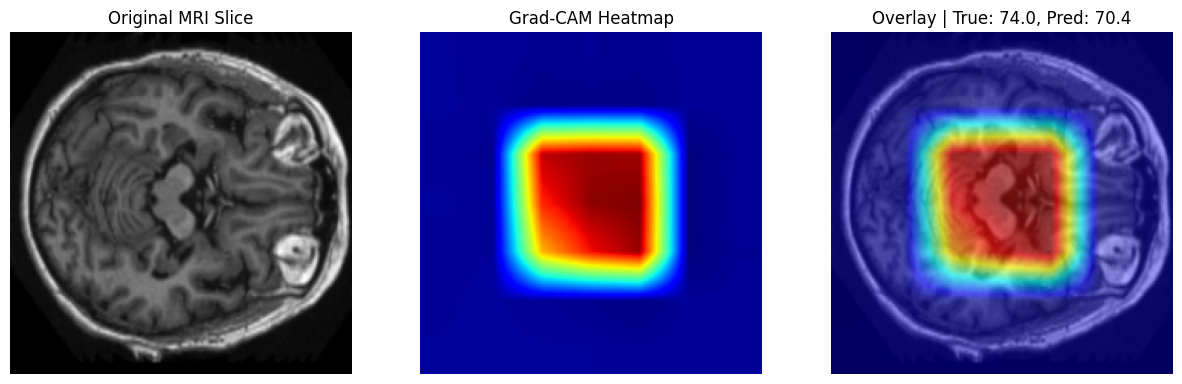

In [31]:
#Grad-CAM cell
import cv2
import numpy as np
import matplotlib.pyplot as plt

gradients = []
activations = []

def save_activation(module, input, output):
    activations.append(output)

def save_gradient(module, grad_input, grad_output):
    gradients.append(grad_output[0])

target_layer = model_xai.features[-1]

handle_forward = target_layer.register_forward_hook(save_activation)
handle_backward = target_layer.register_full_backward_hook(save_gradient)

output = model_xai(input_img)

model_xai.zero_grad()
output.backward()

grads = gradients[0]
acts = activations[0]

weights = torch.mean(grads, dim=(2, 3), keepdim=True)
cam = torch.sum(weights * acts, dim=1).squeeze()
cam = torch.relu(cam)

cam = cam.detach().cpu().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
cam = cv2.resize(cam, (224, 224))

img = input_img.squeeze().detach().cpu().permute(1, 2, 0).numpy()
img = (img - img.min()) / (img.max() - img.min() + 1e-8)

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
heatmap = np.float32(heatmap) / 255

overlay = 0.5 * heatmap + 0.5 * img
overlay = overlay / overlay.max()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original MRI Slice")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Overlay | True: {true_age:.1f}, Pred: {pred_age:.1f}")
plt.axis("off")

plt.show()

handle_forward.remove()
handle_backward.remove()

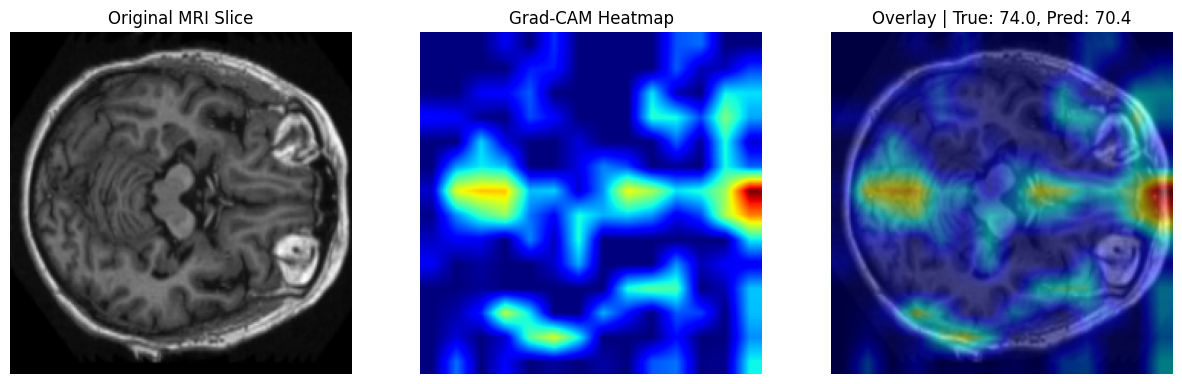

In [32]:
#Grad-CAM cell
import cv2
import numpy as np
import matplotlib.pyplot as plt

gradients = []
activations = []

def save_activation(module, input, output):
    activations.append(output)

def save_gradient(module, grad_input, grad_output):
    gradients.append(grad_output[0])

target_layer = model_xai.features[5]

handle_forward = target_layer.register_forward_hook(save_activation)
handle_backward = target_layer.register_full_backward_hook(save_gradient)

output = model_xai(input_img)

model_xai.zero_grad()
output.backward()

grads = gradients[0]
acts = activations[0]

weights = torch.mean(grads, dim=(2, 3), keepdim=True)
cam = torch.sum(weights * acts, dim=1).squeeze()
cam = torch.relu(cam)

cam = cam.detach().cpu().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
cam = cv2.resize(cam, (224, 224))

img = input_img.squeeze().detach().cpu().permute(1, 2, 0).numpy()
img = (img - img.min()) / (img.max() - img.min() + 1e-8)

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
heatmap = np.float32(heatmap) / 255

overlay = 0.5 * heatmap + 0.5 * img
overlay = overlay / overlay.max()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original MRI Slice")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Overlay | True: {true_age:.1f}, Pred: {pred_age:.1f}")
plt.axis("off")

plt.show()

handle_forward.remove()
handle_backward.remove()

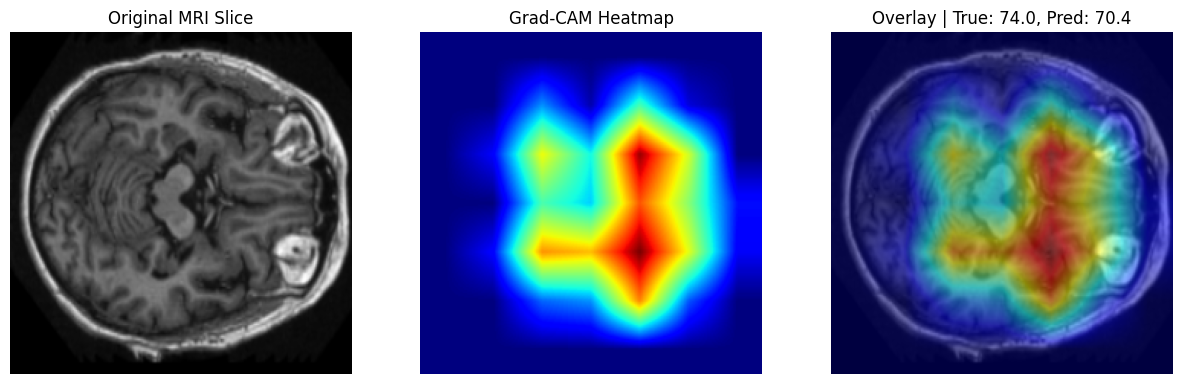

In [33]:
#Grad-CAM cell
import cv2
import numpy as np
import matplotlib.pyplot as plt

gradients = []
activations = []

def save_activation(module, input, output):
    activations.append(output)

def save_gradient(module, grad_input, grad_output):
    gradients.append(grad_output[0])

target_layer = model_xai.features[6]

handle_forward = target_layer.register_forward_hook(save_activation)
handle_backward = target_layer.register_full_backward_hook(save_gradient)

output = model_xai(input_img)

model_xai.zero_grad()
output.backward()

grads = gradients[0]
acts = activations[0]

weights = torch.mean(grads, dim=(2, 3), keepdim=True)
cam = torch.sum(weights * acts, dim=1).squeeze()
cam = torch.relu(cam)

cam = cam.detach().cpu().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
cam = cv2.resize(cam, (224, 224))

img = input_img.squeeze().detach().cpu().permute(1, 2, 0).numpy()
img = (img - img.min()) / (img.max() - img.min() + 1e-8)

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
heatmap = np.float32(heatmap) / 255

overlay = 0.5 * heatmap + 0.5 * img
overlay = overlay / overlay.max()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original MRI Slice")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Overlay | True: {true_age:.1f}, Pred: {pred_age:.1f}")
plt.axis("off")

plt.show()

handle_forward.remove()
handle_backward.remove()

## 11. Conclusion —


1. This notebook completes the model refinement stage of the project.

2. **Key steps:** 

Notebook 1 identified EfficientNet-B0 as the best architecture

Phase 1 compared several training strategies and highlighted dropout as a strong candidate

Phase 2 refined this model through manual hyperparameter tuning.

3. **Final result:** 

Best configuration: Dropout 0.3 + learning rate 5e-5
Best validation subject MAE: 4.3391 years

**Main takeaway:** After selecting a strong architecture, controlled refinement (dropout + learning rate tuning) can significantly improve performance without changing the model backbone.

**Explainability:** Grad-CAM confirms that the model focuses on meaningful brain regions, supporting the reliability of the predictions..



## Final Conclusion

### What was tested

This notebook fixed the architecture to EfficientNet-B0 and compared multiple training variants: baseline, lower learning rate, dropout regularization, and frozen-backbone training.

### What won

The best final tuned setup used dropout (0.3) and a reduced learning rate (5e-5), outperforming other tested refinement variants.

### Main result

Best reported validation Subject MAE reached approximately **4.3391 years**.

### Why this matters

The refinement stage shows that training strategy choices (not just architecture choice) materially affect medical-imaging regression quality.

### Key limitations

- Results are from one dataset context and still need stronger external validation.
- Frozen-feature transfer performed poorly here, but broader experiments could revisit this under different data scales.
- Grad-CAM supports interpretability qualitatively, but further quantitative explainability checks are still needed.